# t-SNE

В этом ноутбуке посмотрим:
- зачем нужен t-SNE и почему его используют **в основном для визуализации**
- чем t-SNE отличается от **PCA**
- как влияет параметр **perplexity**
- почему t-SNE **не всегда подходит** для реального обучения модели
- почему результат меняется из-за **random_state**
- как влияет **масштабирование** признаков

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

## 1. Данные

Возьмём датасет `digits` — изображения цифр 8*8 (64 признака, 10 классов). Он удобен: размерность достаточно высокая, классы легко интерпретировать.

In [9]:
digits = load_digits()
X, y = digits.data, digits.target

df = pd.DataFrame(X)
df['target'] = y
print('Размер данных:', X.shape)
df.head()

Размер данных: (1797, 64)


,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


## 2. PCA в 2D

PCA — **линейный** метод. Он ищет направления максимальной дисперсии. Быстрый, детерминированный, легко применяется к новым данным (`.transform`).

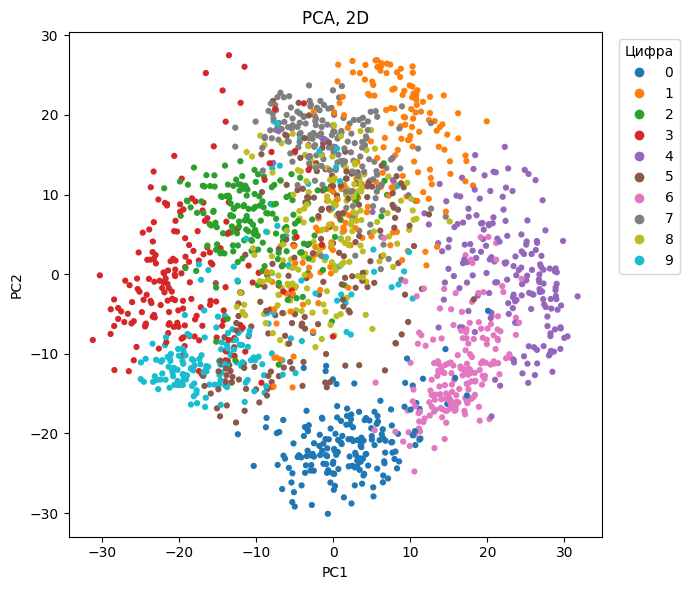

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=12)
plt.legend(*scatter.legend_elements(), title='Цифра', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('PCA, 2D')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout(); plt.show()

Видно, что классы частично перекрываются — линейные проекции не всегда хорошо разделяют сложные структуры.

## 3. t-SNE в 2D

t-SNE — **нелинейный** метод. Он старается сохранить **локальную** структуру: точки, которые были близки в исходном пространстве, остаются близки и в 2D.

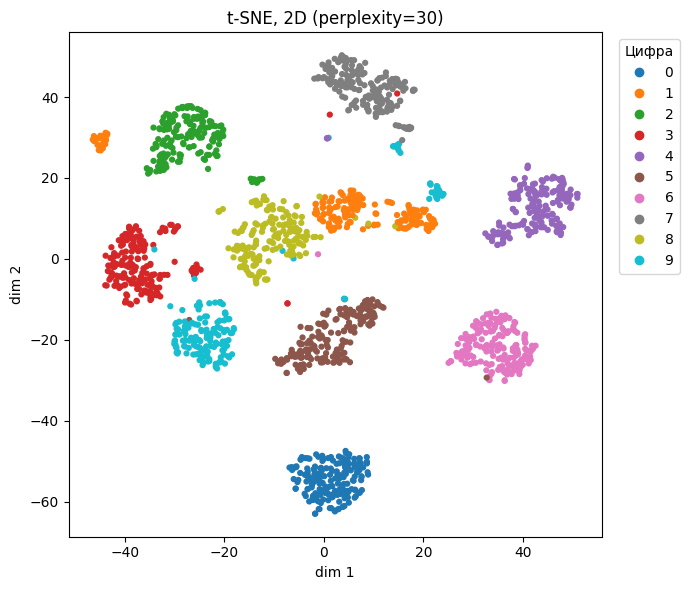

In [4]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=12)
plt.legend(*scatter.legend_elements(), title='Цифра', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('t-SNE, 2D (perplexity=30)')
plt.xlabel('dim 1'); plt.ylabel('dim 2')
plt.tight_layout(); plt.show()

Кластеры разделены **гораздо лучше**, чем у PCA. Именно поэтому t-SNE так любят для визуализации.

## 4. Влияние perplexity

`perplexity` — грубо говоря, «сколько соседей учитывать». Маленькая → t-SNE смотрит на очень локальную структуру (получаются мелкие фрагменты). Большая → структура размазывается. Обычно берут 5–50.

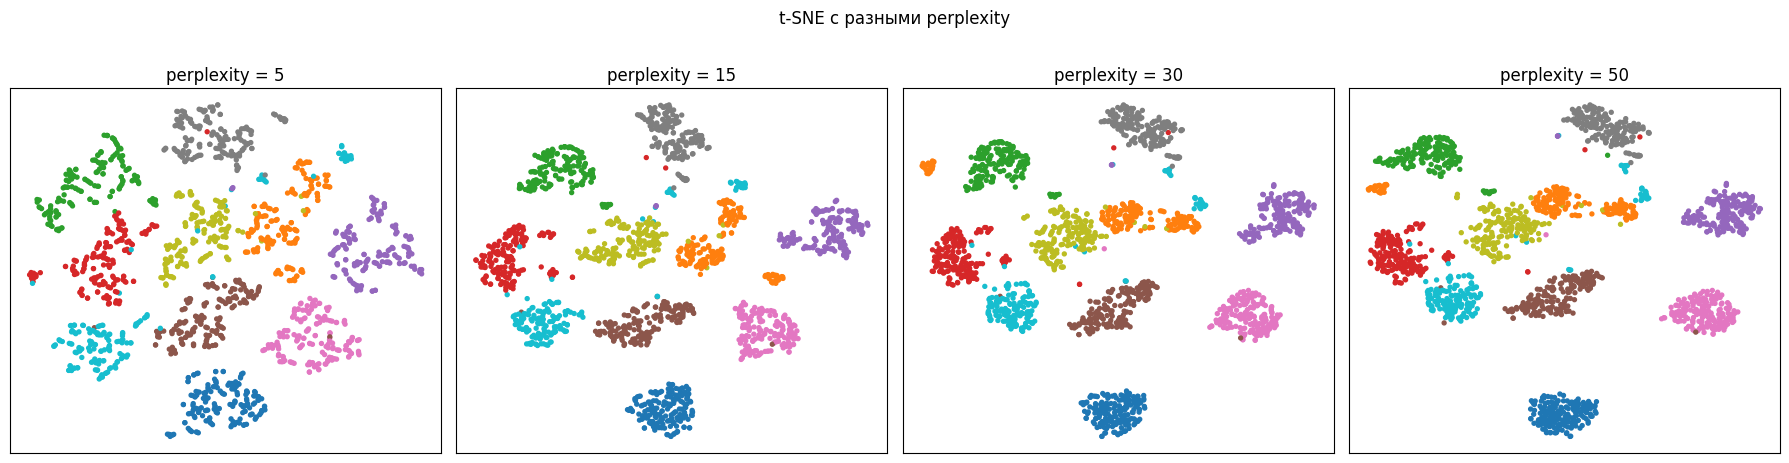

In [5]:
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, p in zip(axes, perplexities):
    emb = TSNE(n_components=2, perplexity=p, random_state=42, init='pca').fit_transform(X)
    ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap='tab10', s=8)
    ax.set_title(f'perplexity = {p}')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('t-SNE с разными perplexity', y=1.02)
plt.tight_layout(); plt.show()

Видно, что при разных значениях форма и расположение кластеров **меняется**. Это — нормальное поведение t-SNE.

## 5. random_state — почему результат «прыгает»

t-SNE стартует со случайной инициализации и оптимизирует нелинейный функционал — поэтому при разных `random_state` картинка получается **разная**, хотя кластеры в целом сохраняются.

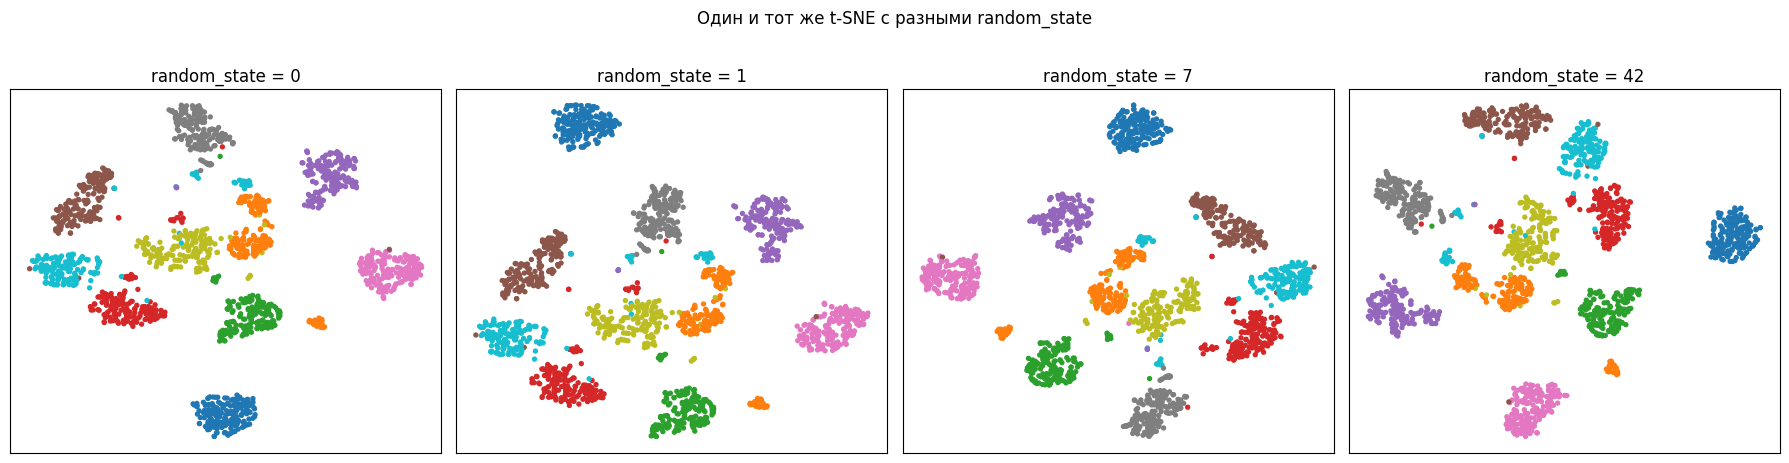

In [6]:
seeds = [0, 1, 7, 42]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, s in zip(axes, seeds):
    emb = TSNE(n_components=2, perplexity=30, random_state=s, init='random').fit_transform(X)
    ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap='tab10', s=8)
    ax.set_title(f'random_state = {s}')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Один и тот же t-SNE с разными random_state', y=1.02)
plt.tight_layout(); plt.show()

Поэтому для воспроизводимости в реальных проектах всегда фиксируют `random_state`.

## 6. Масштабирование: до и после

t-SNE работает с расстояниями, а значит чувствителен к масштабу признаков. Возьмём данные и **искусственно растянем** один признак — посмотрим, что будет до и после `StandardScaler`.

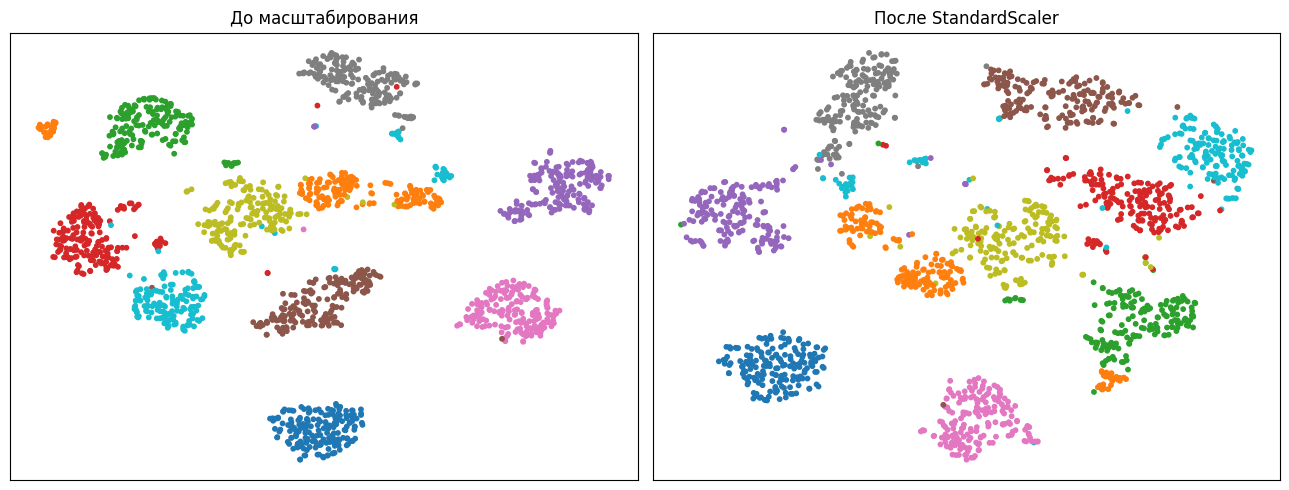

In [7]:
X_skewed = X.copy().astype(float)
X_skewed[:, 0] *= 1000

X_scaled = StandardScaler().fit_transform(X_skewed)

emb_raw    = TSNE(n_components=2, perplexity=30, random_state=42, init='pca').fit_transform(X_skewed)
emb_scaled = TSNE(n_components=2, perplexity=30, random_state=42, init='pca').fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(emb_raw[:, 0], emb_raw[:, 1], c=y, cmap='tab10', s=10)
axes[0].set_title('До масштабирования')
axes[0].set_xticks([]); axes[0].set_yticks([])

axes[1].scatter(emb_scaled[:, 0], emb_scaled[:, 1], c=y, cmap='tab10', s=10)
axes[1].set_title('После StandardScaler')
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.tight_layout(); plt.show()

Без масштабирования один «жирный» признак подавляет всё остальное и кластеры сливаются. После `StandardScaler` структура снова видна.

## 7. Почему t-SNE не подходит для обучения модели

t-SNE — отличный **визуализатор**, но плохой **препроцессор для ML**:

- **Нет `transform` для новых данных.** Для каждого нового объекта пришлось бы запускать t-SNE заново на всём датасете.
- **Случайность.** Разные `random_state` → разные эмбеддинги, нестабильные фичи.
- **Глобальные расстояния не сохраняются.** Расстояние между кластерами в t-SNE может ничего не значить — модель может выучить ложные зависимости.
- **Долго.** Сложность ~O(n²), на больших данных это тяжело.
- **Зависит от гиперпараметров** (`perplexity`, число итераций) — небольшие изменения сильно меняют картину.

#**Общий итог:**

- **PCA** — быстрый, линейный, для общего сжатия и препроцессинга.
- **t-SNE** — нелинейный, красиво показывает кластеры, но только для **визуализации**.
- **perplexity** и **random_state** заметно меняют картинку — фиксируйте их.
- Перед t-SNE почти всегда стоит сделать **масштабирование**.